In [16]:
import os
import torch
from PIL import Image
from facenet_pytorch import MTCNN
from tqdm import tqdm
import matplotlib.pyplot as plt

### Cek GPU terdeteksi

In [17]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Device yang digunakan: {device}")

if device.type == 'cuda':
    print(f"Nama GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU tidak terdeteksi")

Device yang digunakan: cuda:0
Nama GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


### Inisialisas Model MTCNN

In [18]:
# Inisialisasi MTCNN
mtcnn = MTCNN(
    keep_all=False,       
    select_largest=True,  
    margin=60,            
    post_process=False,   
    device=device
)

### Croping Proses

In [19]:
input_dir = '../Data/train_clean/' 
output_dir = '../Data/train_cropped/'

classes = ['realperson', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_mannequin', 'fake_unknown']

for cls in classes:
    os.makedirs(os.path.join(output_dir, cls), exist_ok=True)

total_images = 0
successful_crops = 0

for cls in classes:
    class_input_path = os.path.join(input_dir, cls)
    class_output_path = os.path.join(output_dir, cls)
    
    if not os.path.exists(class_input_path):
        print(f"Folder {cls} tidak ditemukan di input_dir, dilewati.")
        continue
        
    images = os.listdir(class_input_path)
    print(f"\nMemproses kelas: {cls} ({len(images)} gambar)")
    
    for img_name in tqdm(images):
        total_images += 1
        img_path = os.path.join(class_input_path, img_name)
        out_path = os.path.join(class_output_path, img_name)
        
        try:
            img = Image.open(img_path).convert('RGB')

            face = mtcnn(img, save_path=out_path) 
            
            if face is not None:
                successful_crops += 1
                
        except Exception as e:
            pass

print("\n" + "="*30)
print("Ringkasan Cropping")
print(f"Total gambar awal: {total_images}")
print(f"Wajah berhasil dipotong: {successful_crops}")
print(f"Wajah tidak terdeteksi / Dibuang: {total_images - successful_crops}")
print("="*30)


Memproses kelas: realperson (432 gambar)



























































































































































































































































































































































































100%|██████████| 432/432 [02:22<00:00,  3.03it/s]



Memproses kelas: fake_mask (253 gambar)
































































































































































































































































100%|██████████| 253/253 [01:41<00:00,  2.50it/s]



Memproses kelas: fake_printed (131 gambar)


...


Memproses kelas: fake_mannequin (181 gambar)


















































































































100%|██████████| 181/181 [00:21<00:00,  8.60it/s]



Memproses kelas: fake_unknown (360 gambar)




































































































































































100%|██████████| 360/360 [00:20<00:00, 17.17it/s]


Ringkasan Cropping
Total gambar awal: 1555
Wajah berhasil dipotong: 1441
Wajah tidak terdeteksi / Dibuang: 114


### Cek Hasil Croping

Jumlah Data Hasil Cropping per Kelas:
- realperson: 420 gambar
- fake_mask: 251 gambar
- fake_printed: 112 gambar
- fake_screen: 181 gambar
- fake_mannequin: 178 gambar
- fake_unknown: 299 gambar


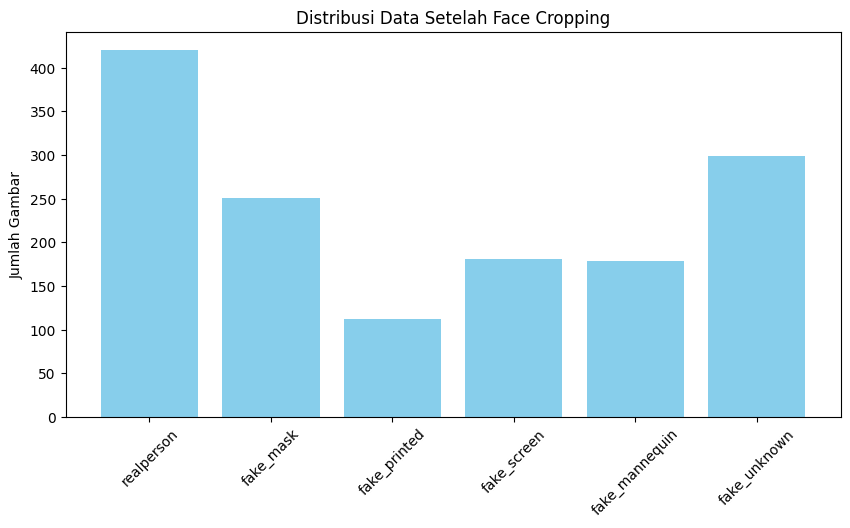

In [20]:
cropped_counts = {}
for cls in classes:
    class_output_path = os.path.join(output_dir, cls)
    if os.path.exists(class_output_path):
        cropped_counts[cls] = len(os.listdir(class_output_path))
    else:
        cropped_counts[cls] = 0

print("Jumlah Data Hasil Cropping per Kelas:")
for cls, count in cropped_counts.items():
    print(f"- {cls}: {count} gambar")

plt.figure(figsize=(10, 5))
plt.bar(cropped_counts.keys(), cropped_counts.values(), color='skyblue')
plt.title('Distribusi Data Setelah Face Cropping')
plt.xticks(rotation=45)
plt.ylabel('Jumlah Gambar')
plt.show()